In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Laser Interferometry

Suppose you have two waves:

$$y_1(t) = \sin(\omega_1 t + \phi_1)$$
$$y_2(t) = \sin(\omega_2 t + \phi_2)$$

Using $\sin \theta_1 + \sin \theta_2 = 2\sin(\frac{\theta_1+\theta_2}{2})\cos(\frac{\theta_1-\theta_2}{2})$ we get the sum of these waves to be,

$$y_1(t)+y_2(t) = 2\sin\Big(\dfrac{\omega_1+\omega_2}{2} t + \dfrac{\phi_1+\phi_2}{2}\Big)\cos\Big(\dfrac{\omega_1-\omega_2}{2} t + \dfrac{\phi_1-\phi_2}{2}\Big)$$

Here the wave $\sin(\frac{\omega_1+\omega_2}{2} t + \frac{\phi_1+\phi_2}{2})$ is the carrier wave and the wave $\cos(\frac{\omega_1-\omega_2}{2} t + \frac{\phi_1-\phi_2}{2})$ is the envelope. Due to high frequencies, the carrier oscillates too rapidly to be measured and hence only the envelope is measured.

Consider an example ignoring phase differences:


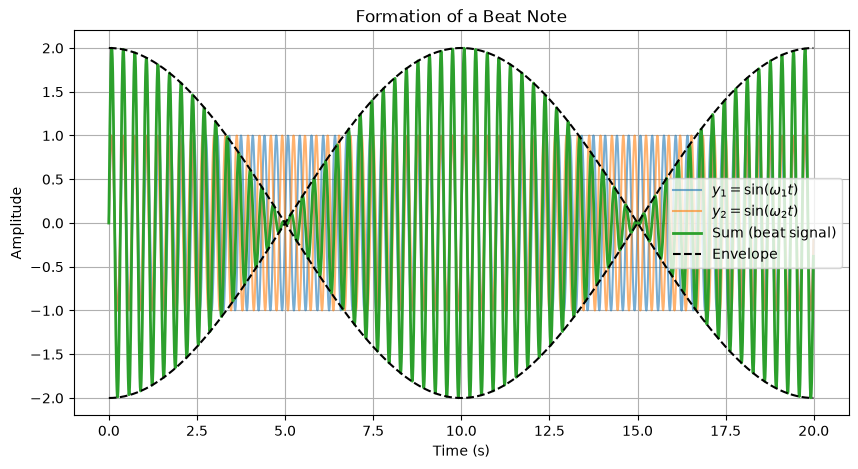

In [83]:
# Frequencies of the two sine waves (Hz)
f1 = 3
f2 = f1 + 0.1

# Convert to angular frequencies (rad/s)
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2

# Time array
t = np.arange(0, 20, 0.01)

# Individual sine waves
y1 = np.sin(w1*t)
y2 = np.sin(w2*t)

# Sum of the two waves (this exhibits beating)
y = y1 + y2

# Beat envelope (modulation)
mod = 2*np.cos((w1 - w2)*t/2)

# Plot everything
plt.figure(figsize=(10, 5))

plt.plot(t, y1, label=r'$y_1=\sin(\omega_1 t)$', alpha=0.6)
plt.plot(t, y2, label=r'$y_2=\sin(\omega_2 t)$', alpha=0.6)

# Resultant signal (carrier modulated by the beat envelope)
plt.plot(t, y, label='Sum (beat signal)', linewidth=2)

# Upper and lower modulation envelopes
plt.plot(t, mod, 'k--', label='Envelope')
plt.plot(t, -mod, 'k--')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Formation of a Beat Note')
plt.legend()
plt.grid(True)
plt.show()

In LISA, each interferometer measures the sum of two incoming lasers. This produces a carrier and an envelope signal where the carrier oscillates too rapidly to be measured. Hence the interferometer measures the frequency and phase of the carrier.

Hence if two interfering lasers have frequencies and phases $\omega_1(t), \omega_2(t)$ and $\phi_1(t), \phi_2(t)$ then the measured frequency and phase of the resulting carrier are proportional to $|\omega_1(t)-\omega_2(t)|$ and $\phi_1(t) - \phi_2(t)$. These are called **beat note frequencies and phases**.

## Time Delay Interferometer

In [93]:
def C1(t, amp=1):
    return amp*(
        np.sin(0.23*t)
        + 0.60*np.sin(0.71*t + 0.3)
        + 0.25*np.sin(1.87*t + 1.4)
    )

def C2(t, amp=1):
    return amp*(
        0.90*np.sin(0.19*t + 1.1)
        + 0.55*np.sin(0.83*t + 2.0)
        + 0.30*np.sin(1.51*t + 0.6)
    )

def C3(t, amp=1):
    return amp*(
        1.10*np.sin(0.27*t + 2.2)
        + 0.45*np.sin(0.91*t + 0.8)
        + 0.35*np.sin(1.63*t + 2.7)
    )

def h(t):
    A = 0.05      # amplitude
    t0 = 20.0     # center time
    sigma = 2.0   # width
    f = 1.5       # oscillation frequency

    return A * np.exp(-((t - t0)**2)/(2*sigma**2)) * np.sin(2*np.pi*f*(t - t0))

In [121]:
L12 = 8.3
L13 = 8.4
L23 = 8.2

tau12 = 5.0
tau21 = 20.4

tau13 = 6.8
tau31 = 27.2

tau23 = 7.6
tau32 = 28.0

def y12(t, amp1=1, amp2=1):
    return C2(t-L12, amp2) - C1(t, amp1) + h(t-tau12)

def y21(t, amp1=1, amp2=1):
    return C1(t-L12, amp1) - C2(t, amp2) + h(t-tau21)

def y13(t, amp1=1, amp3=1):
    return C3(t-L13, amp3) - C1(t, amp1) + h(t-tau13)

def y31(t, amp1=1, amp3=1):
    return C1(t-L13, amp1) - C3(t, amp3) + h(t-tau31)

def y23(t, amp2=1, amp3=1):
    return C3(t-L23, amp3) - C2(t, amp2) + h(t-tau23)

def y32(t, amp2=1, amp3=1):
    return C2(t-L23, amp2) - C3(t, amp3) + h(t-tau32)

Consider an interferometer in one of the LISA spacecraft $i$ receiving a laser from spacecraft $j$. The resulting beatnote frequency or phase would have two contributions:

1. due to inherent laser noise flunctuations and 
2. due to gravitational waves causing frequency and phase shifts in the incoming lasers.

We can ignore the beat note phases for now and focus on the frequencies. The analysis is the same for phases. Now the beatnote frequency in link $ij$ could be written as,

$$y_{ij}(t) = y^{\text{GW}}_{ij}(t) + y^{\text{laser}}_{ij}(t)$$

Now $y^{\text{laser}}_{ij}(t)$ would simply be the difference between the laser noise frequency of incoming laser from spacecraft 2 (denoted by $C_j(t)$) and frequency of local laser on spacecraft 1 (denoted by $C_i(t)$). Also as the former has travelled a distance $L_{ij}$ so the frequency we consider would be delayed as,

$$y_{ij}(t) = y^{\text{GW}}_{ij}(t) + C_{j}\Big(t-\frac{L_{ij}}{c}\Big)-C_i(t)$$

**Goal:** To add up $y_{ij}(t)$ in such a way that the beatnote frequencies due to laser noise completely cancels and the one due to GWs remains.

### Translating signals

First consider the $12$ interferometer which has beatnotes:

$$y_{12}(t) = y^{\text{GW}}_{12}(t) + C_{2}\Big(t-\frac{L_{12}}{c}\Big)-C_1(t)$$

Same way consider the $21$ interferometer with beatnotes:

$$y_{21}(t) = y^{\text{GW}}_{21}(t) + C_{1}\Big(t-\frac{L_{21}}{c}\Big)-C_2(t)$$

Since we assume $L_{12}=L_{21}$ we can add these two, to remove dependence on $C_2$ as,

$$y_{12}(t)+y_{21}\Big(t-\frac{L_{21}}{c}\Big) = y^{\text{GW}}_{12}(t)+ y^{\text{GW}}_{21}\Big(t-\frac{L_{21}}{c}\Big)+ C_{1}\Big(t-\frac{2L_{21}}{c}\Big) - C_1(t)$$

Here the GW induced beatnotes are dependent on path so lasers going from SC 1 to 2 will not be same as 2 to 1. Hence $y^{\text{GW}}_{12}(t)$ and $y^{\text{GW}}_{21}(t)$ will not cancel.

Therefore from now on we will ignore the GW terms while writing the sums as,

$$y_{12}(t)+y_{21}\Big(t-\frac{L_{21}}{c}\Big) := C_{1}\Big(t-\frac{2L_{21}}{c}\Big) - C_1(t)$$


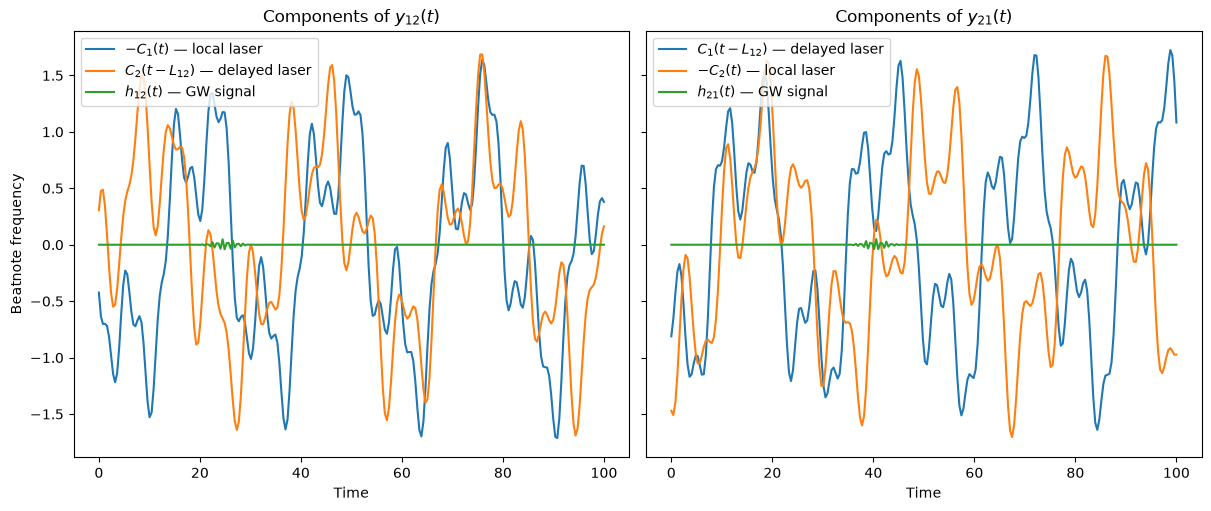

In [130]:
t = np.linspace(0, 100, 250)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True,
    constrained_layout=True
)

# y12(t) = C2(t-L12) - C1(t) + h(t-tau12)
axes[0].plot(t, -C1(t), label=r'$-C_1(t)$ — local laser')
axes[0].plot(t, C2(t-L12), label=r'$C_2(t-L_{12})$ — delayed laser')
axes[0].plot(t, h(t-tau12), label=r'$h_{12}(t)$ — GW signal')
axes[0].set_title(r'Components of $y_{12}(t)$')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Beatnote frequency')
axes[0].legend()

# y21(t) = C1(t-L12) - C2(t) + h(t-tau21)
axes[1].plot(t, C1(t-L12), label=r'$C_1(t-L_{12})$ — delayed laser')
axes[1].plot(t, -C2(t), label=r'$-C_2(t)$ — local laser')
axes[1].plot(t, h(t-tau21), label=r'$h_{21}(t)$ — GW signal')
axes[1].set_title(r'Components of $y_{21}(t)$')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.show()

#### Exercise: Try changing the strength of C2 to see if the combination is effected. Now try for C1. 

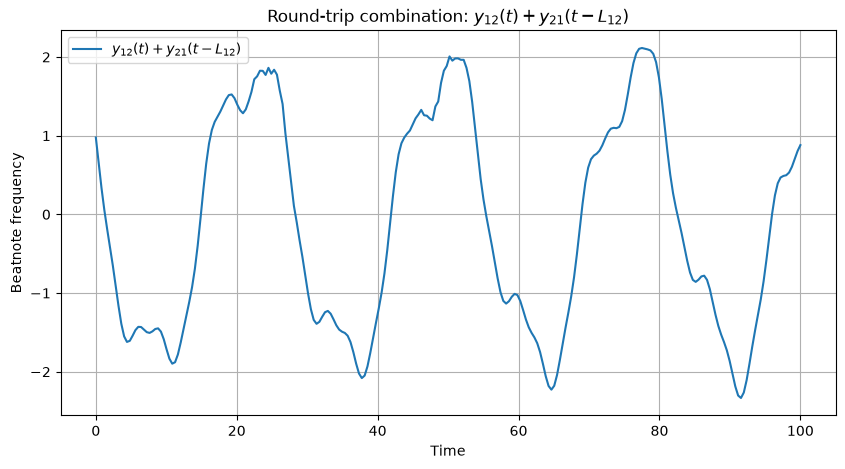

In [131]:
amp1, amp2 = 1, 14

plt.figure(figsize=(10, 5))

# Round-trip combination:
# y12(t) + y21(t-L12)

round_trip = (
    y12(t, amp1=amp1, amp2=amp2)
    + y21(t-L12, amp1=amp1, amp2=amp2)
)

plt.plot(
    t,
    round_trip,
    label=r'$y_{12}(t)+y_{21}(t-L_{12})$'
)

plt.xlabel('Time')
plt.ylabel('Beatnote frequency')
plt.title(r'Round-trip combination: $y_{12}(t)+y_{21}(t-L_{12})$')
plt.legend()
plt.grid(True)

plt.show()

#### Exercise: Try the same for the 13 and 31 interferometers. Express their combo in terms of C1 only by cancelling C3. Try plotting the results.

In [ ]:
# Your code here.

<details>
<summary>Click to reveal solution</summary>

You should now have something like:

$$y_{12}(t)+y_{21}\Big(t-\frac{L_{12}}{c}\Big) := C_{1}\Big(t-\frac{2L_{12}}{c}\Big) - C_1(t)$$
$$y_{13}(t)+y_{31}\Big(t-\frac{L_{13}}{c}\Big) := C_{1}\Big(t-\frac{2L_{13}}{c}\Big) - C_1(t)$$

</details>

We are still not done as we need to cancel out the $C_1$ terms. The key is to find two ways to add these equations to get,

$$\text{expression 1}= C_1(\text{something})-C_1(t)$$
$$\text{expression 2}= C_1(\text{same something})-C_1(t)$$

Then we have $\text{expression 1}-\text{expression 2}=0$. We would have successfully cancelled
beatnote fluctuations due to laser noise.

#### Exercise: Try to find expression 1 and 2. Hint: translate signals in time as we did before to cancel terms.

<details>
<summary>Click to reveal solution</summary>

$$y_{12}(t)+y_{21}\Big(t-\frac{L_{12}}{c}\Big)+ y_{13}(t-\frac{2L_{12}}{c})+y_{31}\Big(t-\frac{L_{13}}{c}-\frac{2L_{12}}{c}\Big) := C_{1}\Big(t-\frac{2L_{12}}{c}-\frac{2L_{13}}{c}\Big) - C_1(t)$$
$$y_{13}(t)+y_{31}\Big(t-\frac{L_{13}}{c}\Big)+ y_{13}(t-\frac{2L_{13}}{c})+y_{31}\Big(t-\frac{L_{12}}{c}-\frac{2L_{13}}{c}\Big) := C_{1}\Big(t-\frac{2L_{12}}{c}-\frac{2L_{13}}{c}\Big) - C_1(t)$$

Hence the $X$ TDI channel is written as,

\begin{aligned}
X(t) = y_{12}(t)+y_{21}\Big(t-\frac{L_{12}}{c}\Big)+ y_{13}(t-\frac{2L_{12}}{c})+y_{31}\Big(t-\frac{L_{13}}{c}-\frac{2L_{12}}{c}\Big) \\
-y_{13}(t)-y_{31}\Big(t-\frac{L_{13}}{c}\Big)- y_{13}(t-\frac{2L_{13}}{c})-y_{31}\Big(t-\frac{L_{12}}{c}-\frac{2L_{13}}{c}\Big)
\end{aligned}

This combination is completely devoid of laser noise.

</details>

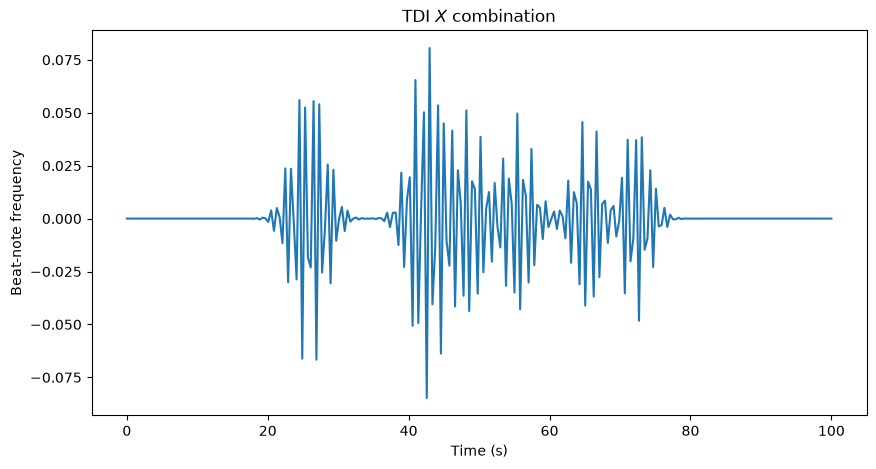

In [ ]:
# Try making the laser noise as strong as possible and see if it affects
# the TDI combination. The laser noise should cancel even when its
# amplitude is much larger than the GW signal. What you see here is purely the signal.

amp1, amp2, amp3 = 100, 10990, 1009

X = (
    y12(t, amp1=amp1, amp2=amp2)
    + y21(t - L12, amp1=amp1, amp2=amp2)
    + y13(t - 2*L12, amp1=amp1, amp3=amp3)
    + y31(t - L13 - 2*L12, amp1=amp1, amp3=amp3)
    -
    (
        y13(t, amp1=amp1, amp3=amp3)
        + y31(t - L13, amp1=amp1, amp3=amp3)
        + y12(t - 2*L13, amp1=amp1, amp2=amp2)
        + y21(t - L12 - 2*L13, amp1=amp1, amp2=amp2)
    )
)

plt.figure(figsize=(10, 5))

plt.plot(t, X)

plt.xlabel('Time (s)')
plt.ylabel('Beat-note frequency')
plt.title(r'TDI $X$ combination')
plt.show()

#### Exercise: Try to derive two more such combinations for SC 2 and 3. These are called the Y and Z channels respectively.

#### Exercise: Try to apply this logic to LIGO and see why laser noise is not a problem in that setup